In [1]:
#Importing Data
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("Path to dataset files:", path)

c:\Users\woute\Documents\RoboticsProjectsLocal\DataScienceProject\DSProject\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 5.20G/5.20G [05:35<00:00, 16.6MB/s]

Extracting files...


Path to dataset files: C:\Users\woute\.cache\kagglehub\datasets\kmader\skin-cancer-mnist-ham10000\versions\2


Total Images found: 10015
Metadata entries: 10015

Unique Classes:
['Benign keratosis-like lesions' 'Melanocytic nevi' 'Dermatofibroma'
 'Melanoma' 'Vascular lesions' 'Basal cell carcinoma' 'Actinic keratoses']

Amount of images per class:
cell_type
Melanocytic nevi                 6705
Melanoma                         1113
Benign keratosis-like lesions    1099
Basal cell carcinoma              514
Actinic keratoses                 327
Vascular lesions                  142
Dermatofibroma                    115
Name: count, dtype: int64


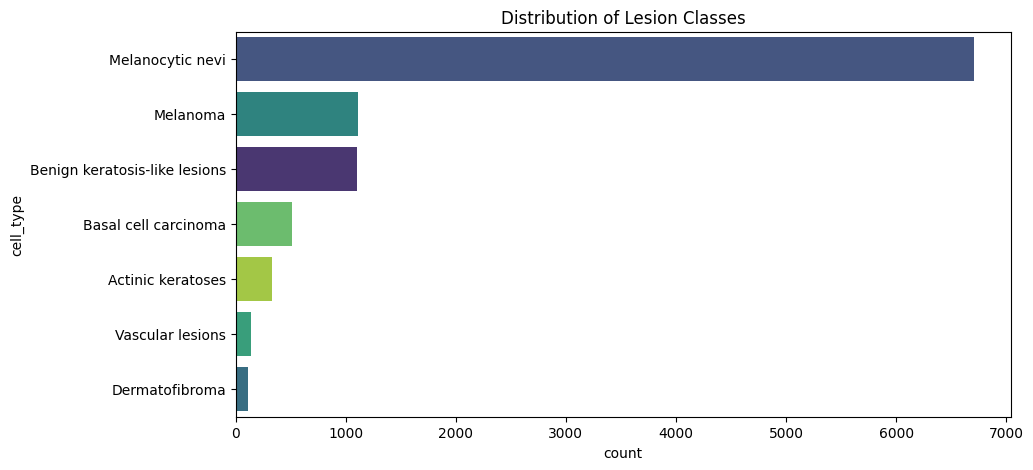

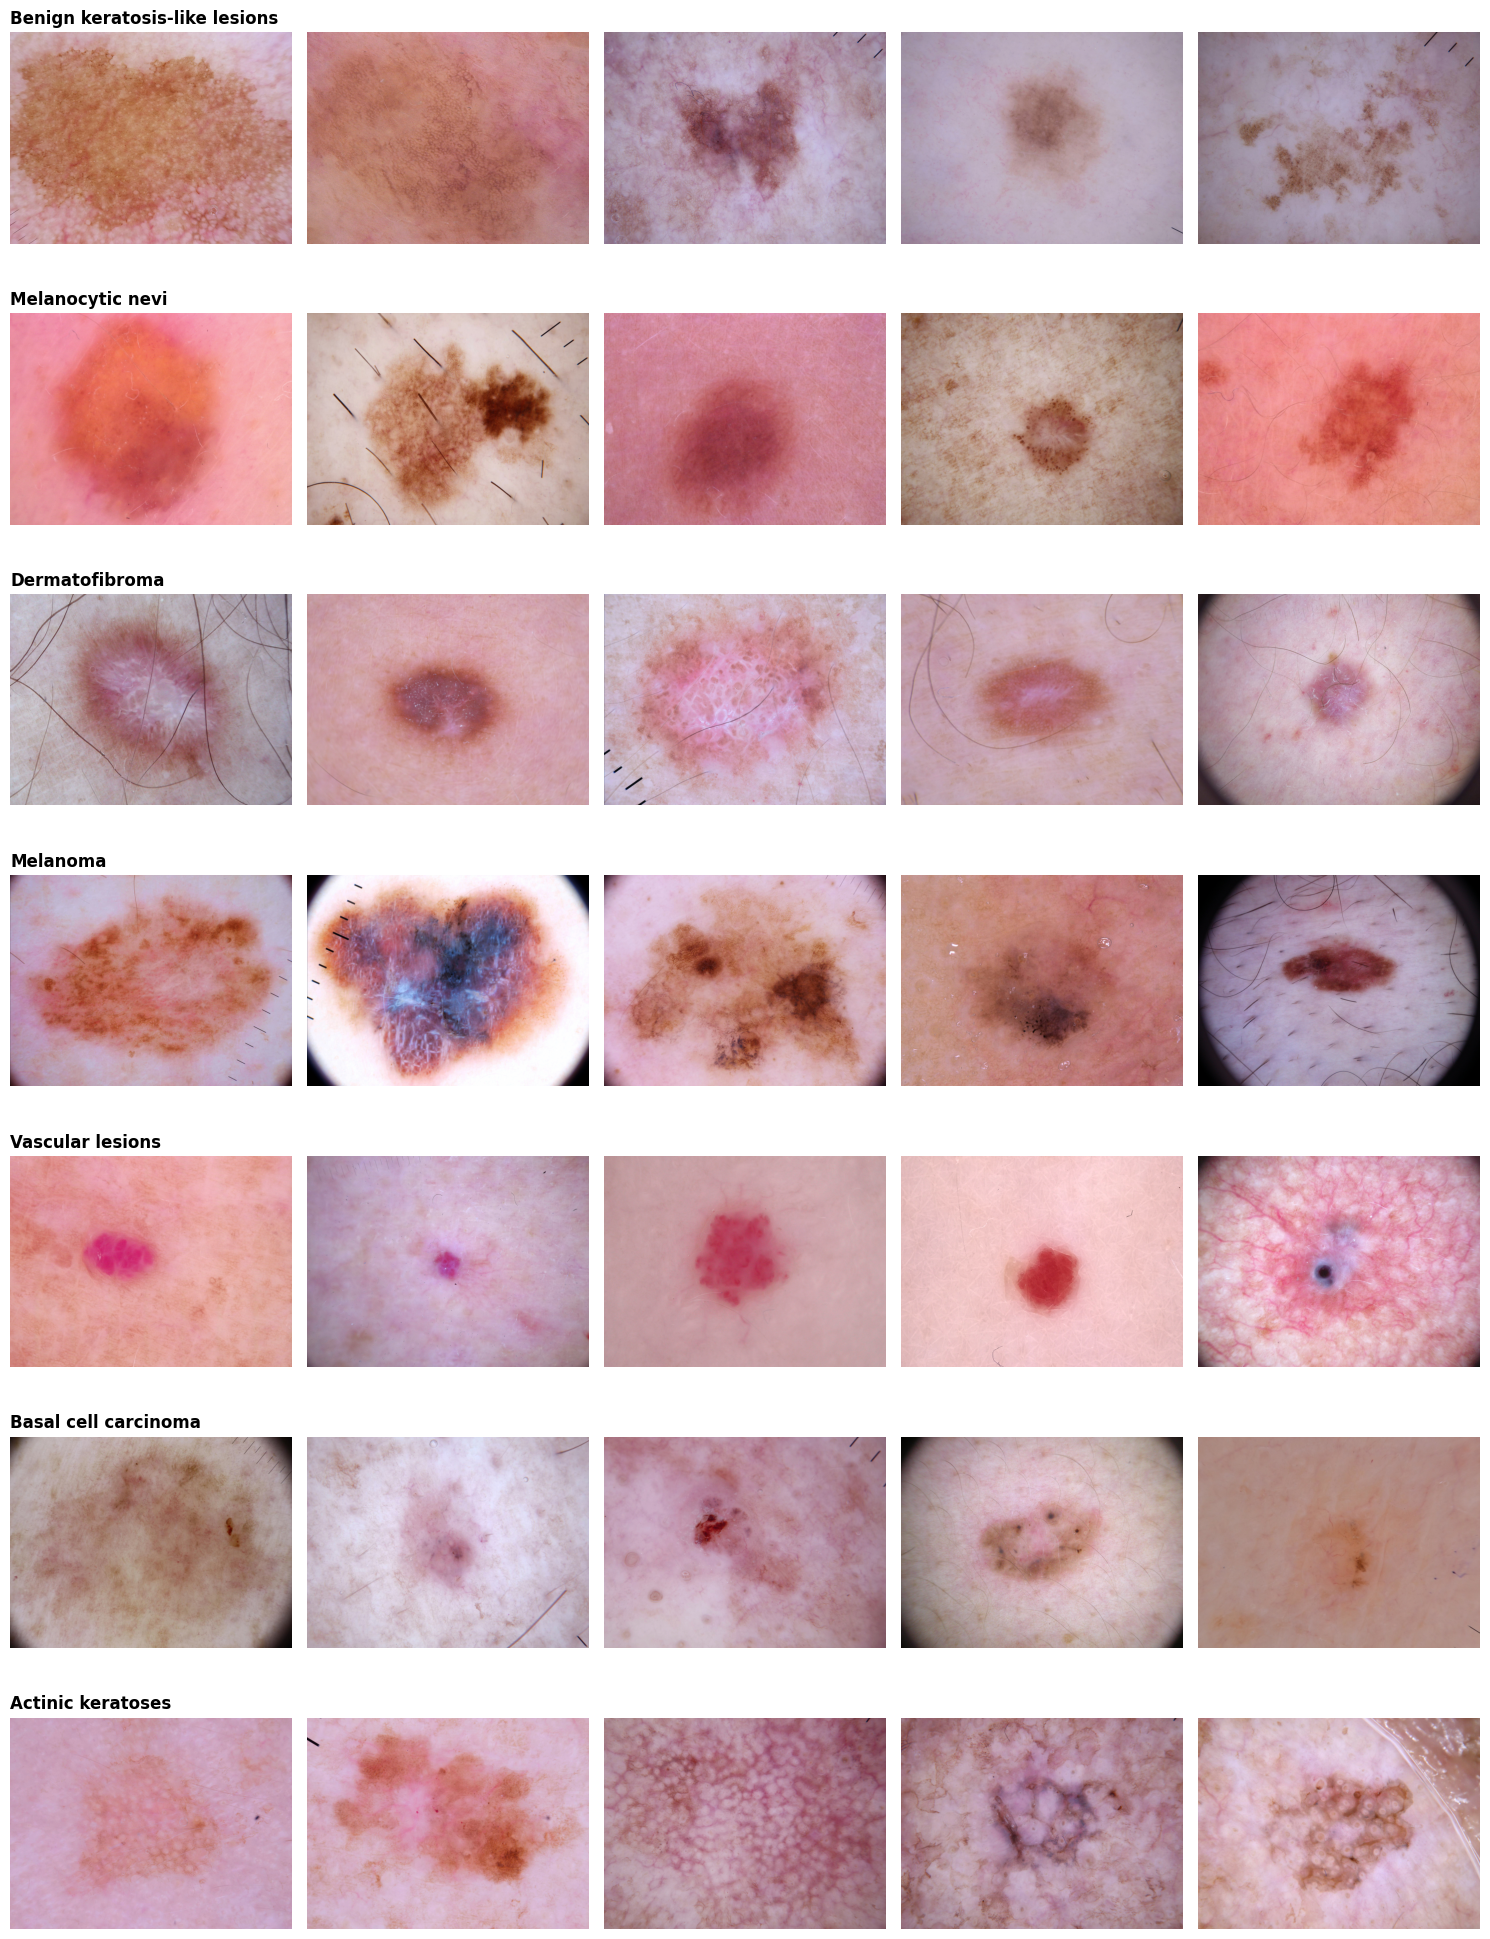

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
from PIL import Image

# 1. Setup paths with recursive search
# '**' with recursive=True looks in all subfolders
all_images = glob(os.path.join(path, '**', '*.jpg'), recursive=True)
all_image_path = {os.path.basename(x).split('.')[0]: x for x in all_images}

# 2. Load Metadata (looking for the HAM10000_metadata.csv)
csv_files = glob(os.path.join(path, '**', '*.csv'), recursive=True)

if not csv_files:
    raise FileNotFoundError("Could not find the CSV metadata file. Check the path content.")

df = pd.read_csv(csv_files[0])

# 3. Map images to metadata
df['path'] = df['image_id'].map(all_image_path.get)

# 4. Map lesion type codes
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}
df['cell_type'] = df['dx'].map(lesion_type_dict.get)

# --- ANALYSIS & PRINTING ---
print(f"Total Images found: {len(all_images)}")
print(f"Metadata entries: {len(df)}")
print("\nUnique Classes:")
print(df['cell_type'].unique())

print("\nAmount of images per class:")
print(df['cell_type'].value_counts())

# --- VISUALIZATION ---
# Plotting class distribution
plt.figure(figsize=(10,5))
sns.countplot(y=df['cell_type'], order=df['cell_type'].value_counts().index, hue=df['cell_type'], palette='viridis', legend=False)
plt.title('Distribution of Lesion Classes')
plt.show()

# Displaying sample images
n_samples = 5
unique_types = df['cell_type'].unique()
fig, m_axs = plt.subplots(len(unique_types), n_samples, figsize=(15, 20))

for n_idx, type_name in enumerate(unique_types):
    type_rows = df[df['cell_type'] == type_name].sample(n_samples, random_state=42)
    for i, (_, c_row) in enumerate(type_rows.iterrows()):
        ax = m_axs[n_idx, i]
        img = Image.open(c_row['path'])
        ax.imshow(img)
        ax.set_axis_off()
        if i == 0:
            ax.set_title(type_name, loc='left', fontweight='bold')

plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import os
import shutil
from PIL import Image
from tqdm import tqdm

# 1. Setup paths
output_dir = "balanced_dataset"
if os.path.exists(output_dir):
    shutil.rmtree(output_dir)
os.makedirs(output_dir)

# Create subfolders for each class
for l_type in df['cell_type'].unique():
    os.makedirs(os.path.join(output_dir, l_type), exist_ok=True)

# List to store new metadata rows
balanced_metadata_list = []

print("Creating balanced dataset with full metadata...")

for lesion_type, group in tqdm(df.groupby('cell_type')):
    target_folder = os.path.join(output_dir, lesion_type)
    
    # Define sampling/augmentation logic
    if lesion_type in ['Melanocytic nevi', 'Melanoma', 'Benign keratosis-like lesions']:
        selected = group.sample(1000, random_state=42)
        multiplier = 1
    elif lesion_type == 'Basal cell carcinoma':
        selected = group
        multiplier = 2
    elif lesion_type in ['Actinic keratoses', 'Vascular lesions', 'Dermatofibroma']:
        selected = group
        multiplier = 3

    for _, row in selected.iterrows():
        # Load image once to rotate if needed
        img_path = row['path']
        img_id = row['image_id']
        original_img = Image.open(img_path)
        
        # --- 1. Save Original ---
        new_filename = f"{img_id}.jpg"
        original_img.save(os.path.join(target_folder, new_filename))
        
        # Create metadata entry (copying all original columns)
        new_row = row.to_dict()
        new_row['image_id'] = img_id # Keep same ID or update as needed
        new_row['path'] = os.path.join(target_folder, new_filename)
        balanced_metadata_list.append(new_row)
        
        # --- 2. Save Rotation 90 ---
        if multiplier >= 2:
            rot90_filename = f"rot90_{img_id}.jpg"
            original_img.rotate(90).save(os.path.join(target_folder, rot90_filename))
            
            row_90 = row.to_dict()
            row_90['image_id'] = f"rot90_{img_id}"
            row_90['path'] = os.path.join(target_folder, rot90_filename)
            balanced_metadata_list.append(row_90)
            
        # --- 3. Save Rotation 180 ---
        if multiplier >= 3:
            rot180_filename = f"rot180_{img_id}.jpg"
            original_img.rotate(180).save(os.path.join(target_folder, rot180_filename))
            
            row_180 = row.to_dict()
            row_180['image_id'] = f"rot180_{img_id}"
            row_180['path'] = os.path.join(target_folder, rot180_filename)
            balanced_metadata_list.append(row_180)

# 3. Save the new metadata to a CSV in the local folder
df_balanced_final = pd.DataFrame(balanced_metadata_list)
df_balanced_final.to_csv(os.path.join(output_dir, "balanced_metadata.csv"), index=False)

print(f"\nProcess Complete!")
print(f"Total images in balanced set: {len(df_balanced_final)}")
print(f"Metadata saved to: {os.path.join(output_dir, 'balanced_metadata.csv')}")

# Display first few rows to verify metadata preservation
df_balanced_final.head()

Creating balanced dataset with full metadata...


100%|██████████| 7/7 [00:37<00:00,  5.36s/it]


Process Complete!
Total images in balanced set: 5780
Metadata saved to: balanced_dataset\balanced_metadata.csv


,lesion_id,image_id,dx,dx_type,age,sex,localization,path,cell_type
0,HAM_0002644,ISIC_0029417,akiec,histo,80.0,female,neck,balanced_dataset\Actinic keratoses\ISIC_002941...,Actinic keratoses
1,HAM_0002644,rot90_ISIC_0029417,akiec,histo,80.0,female,neck,balanced_dataset\Actinic keratoses\rot90_ISIC_...,Actinic keratoses
2,HAM_0002644,rot180_ISIC_0029417,akiec,histo,80.0,female,neck,balanced_dataset\Actinic keratoses\rot180_ISIC...,Actinic keratoses
3,HAM_0006002,ISIC_0029915,akiec,histo,50.0,female,face,balanced_dataset\Actinic keratoses\ISIC_002991...,Actinic keratoses
4,HAM_0006002,rot90_ISIC_0029915,akiec,histo,50.0,female,face,balanced_dataset\Actinic keratoses\rot90_ISIC_...,Actinic keratoses


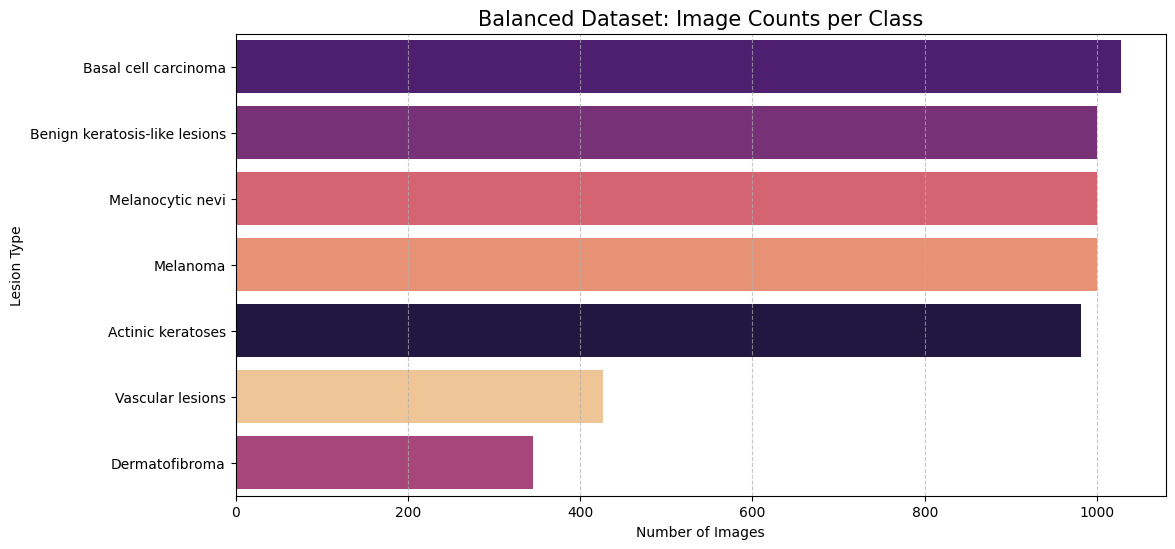

Balanced Class Distribution:
cell_type
Basal cell carcinoma             1028
Benign keratosis-like lesions    1000
Melanocytic nevi                 1000
Melanoma                         1000
Actinic keratoses                 981
Vascular lesions                  426
Dermatofibroma                    345
Name: count, dtype: int64


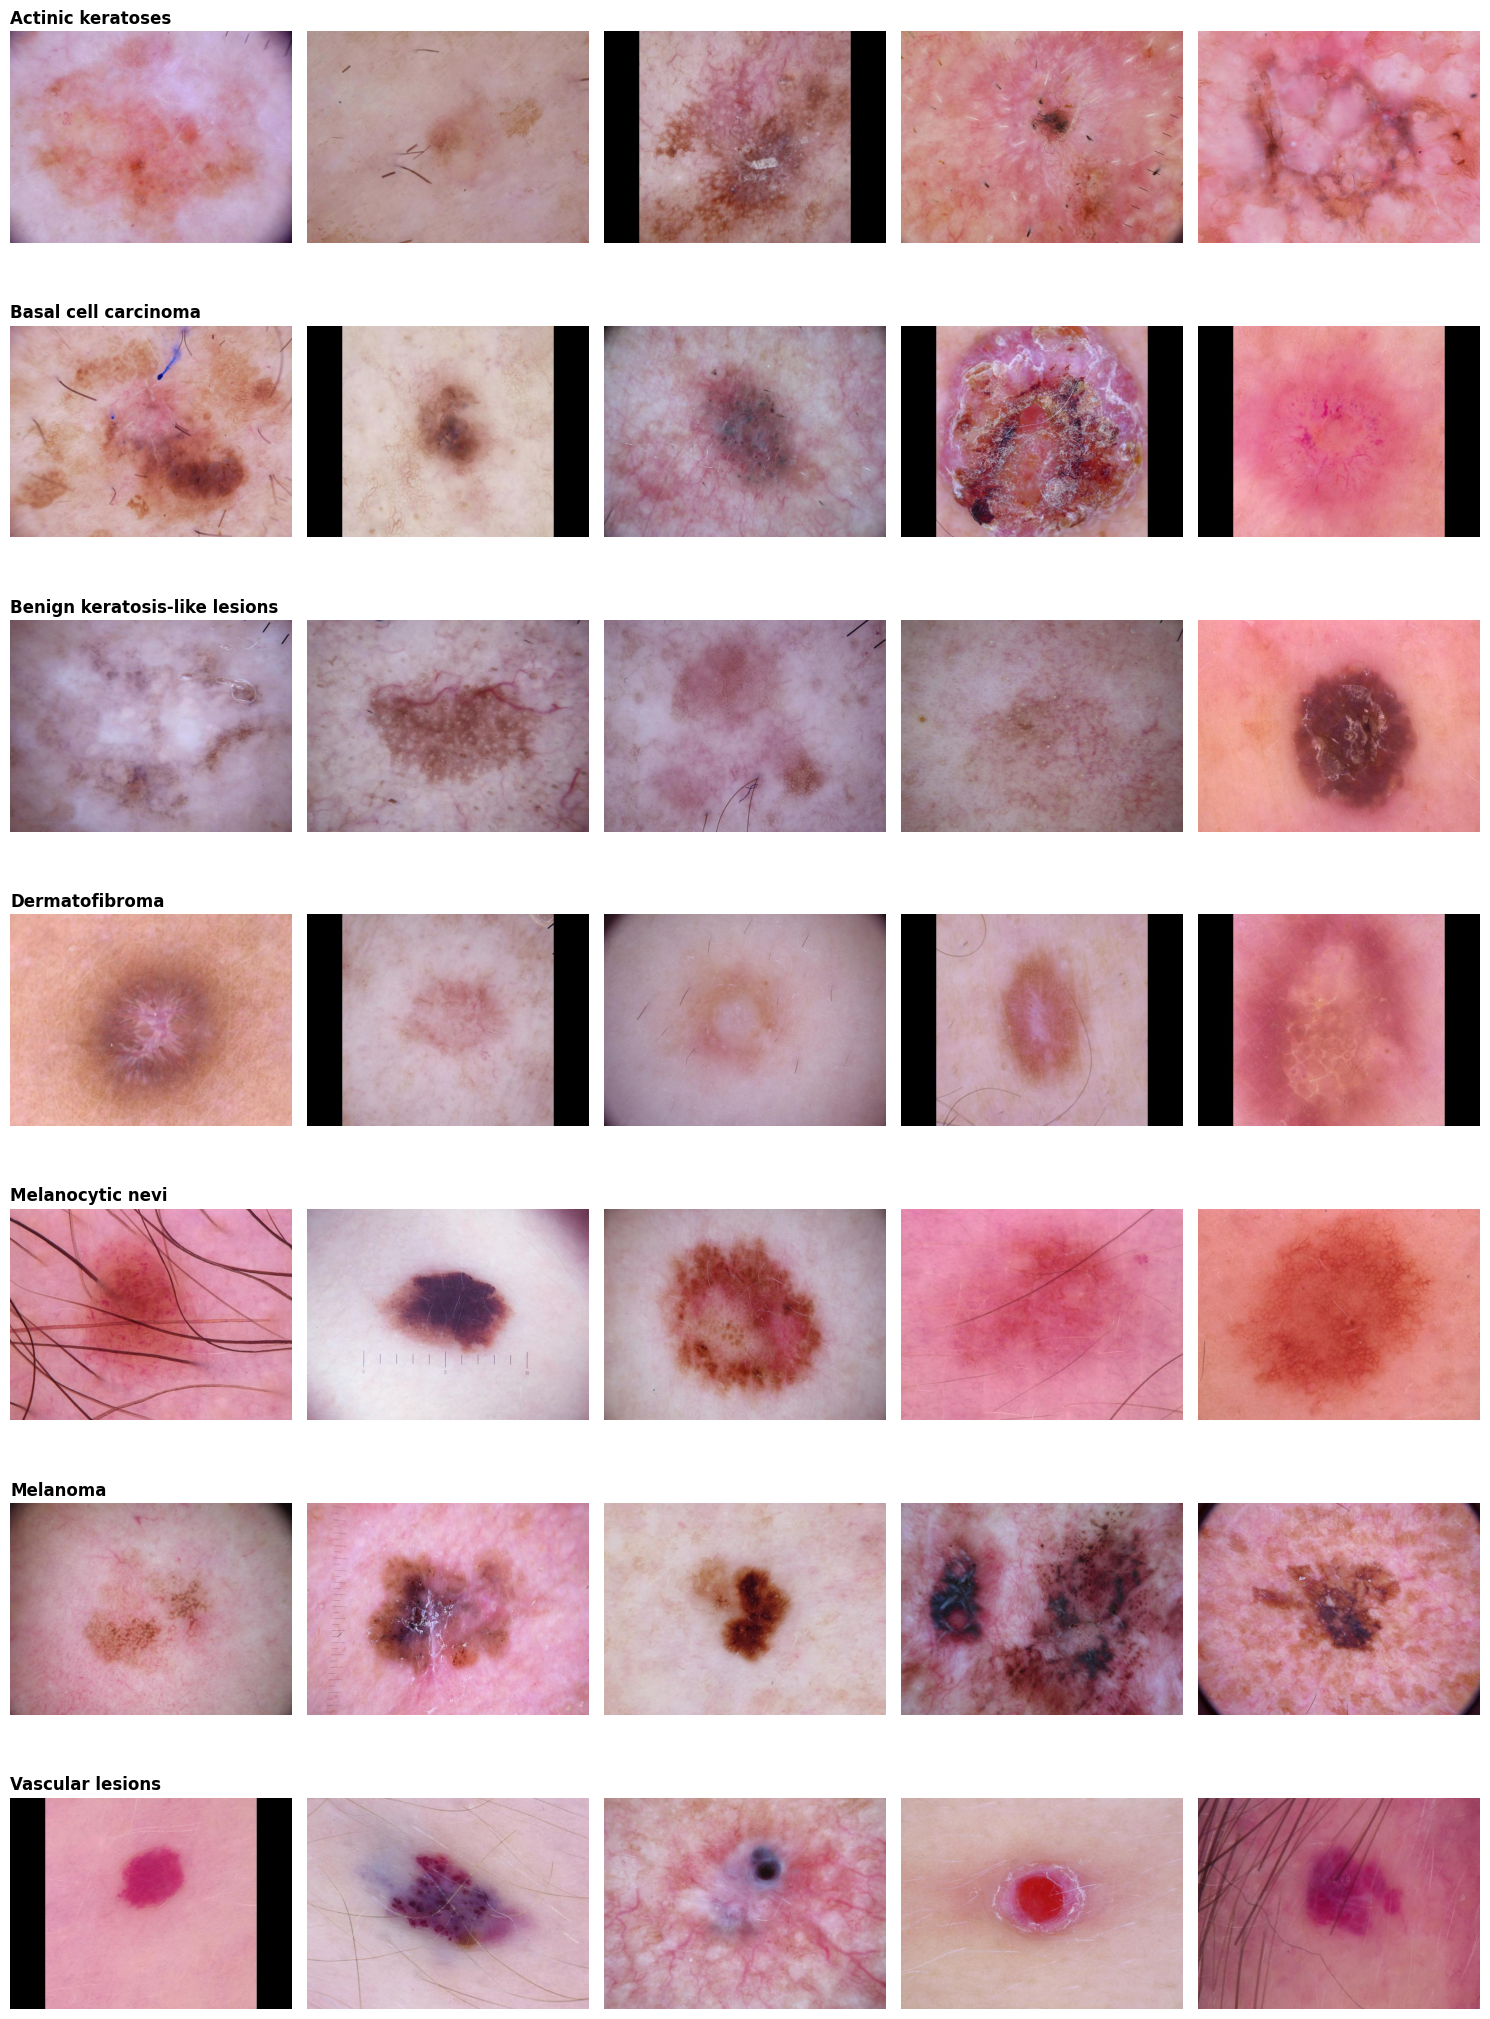

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# --- 1. PLOT HISTOGRAM ---
plt.figure(figsize=(12, 6))
# Using countplot for the histogram of classes
sns.countplot(
    y=df_balanced_final['cell_type'], 
    order=df_balanced_final['cell_type'].value_counts().index, 
    hue=df_balanced_final['cell_type'],
    palette='magma',
    legend=False
)
plt.title('Balanced Dataset: Image Counts per Class', fontsize=15)
plt.xlabel('Number of Images')
plt.ylabel('Lesion Type')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# --- 2. PRINT CLASS COUNTS ---
print("Balanced Class Distribution:")
print(df_balanced_final['cell_type'].value_counts())

# --- 3. VISUALIZE 5 EXAMPLES PER CLASS ---
unique_classes = df_balanced_final['cell_type'].unique()
n_samples = 5

fig, axes = plt.subplots(len(unique_classes), n_samples, figsize=(15, 3 * len(unique_classes)))

for idx, lesion_type in enumerate(unique_classes):
    # Filter images for this specific class
    class_df = df_balanced_final[df_balanced_final['cell_type'] == lesion_type]
    
    # Pick 5 random samples
    samples = class_df.sample(n_samples, random_state=42)
    
    for i, (_, row) in enumerate(samples.iterrows()):
        ax = axes[idx, i]
        img = Image.open(row['path'])
        ax.imshow(img)
        ax.axis('off')
        
        # Add labels to the first image of each row
        if i == 0:
            ax.set_title(lesion_type, loc='left', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import os
import shutil
from tqdm import tqdm

# 1. Setup paths
original_output_dir = "imbalanced_dataset"

# Reset the folder if it exists to ensure a clean copy
if os.path.exists(original_output_dir):
    shutil.rmtree(original_output_dir)
os.makedirs(original_output_dir)

# Create subfolders for each class based on the original data
for l_type in df['cell_type'].unique():
    os.makedirs(os.path.join(original_output_dir, l_type), exist_ok=True)

# 2. Copy the images into their respective class folders
print("Copying original imbalanced dataset into local folders...")

# We use the original 'df' from the very first step which contains all 10,015 entries
for _, row in tqdm(df.iterrows(), total=len(df)):
    img_id = row['image_id']
    lesion_type = row['cell_type']
    src_path = row['path']
    
    # Define destination path: imbalanced_dataset/Class_Name/image_id.jpg
    dest_path = os.path.join(original_output_dir, lesion_type, f"{img_id}.jpg")
    
    # Copy file
    shutil.copy(src_path, dest_path)

# 3. Save the original metadata into this new folder for reference
# We'll update the 'path' column in this CSV to point to the new local location
df_imbalanced_local = df.copy()
df_imbalanced_local['path'] = df_imbalanced_local.apply(
    lambda x: os.path.join(original_output_dir, x['cell_type'], f"{x['image_id']}.jpg"), axis=1
)
df_imbalanced_local.to_csv(os.path.join(original_output_dir, "imbalanced_metadata.csv"), index=False)

print(f"\nSuccess! Imbalanced dataset organized at: {os.path.abspath(original_output_dir)}")
print(f"Total images copied: {len(df_imbalanced_local)}")

Copying original imbalanced dataset into local folders...


100%|██████████| 10015/10015 [03:11<00:00, 52.20it/s]



Success! Imbalanced dataset organized at: c:\Users\woute\Documents\RoboticsProjectsLocal\DataScienceProject\mic_project\imbalanced_dataset
Total images copied: 10015
